we have 
- frame A
- flow map (which says where will all the pixels in the frame A move eg:- 10 units to the right)

now we just create the middle frame . this process is called warping 

both the input and the output is in the dataset folder 
input - triplets and flow 
outpiut - warped folder inside datasets

In [1]:
import torch.nn.functional as F
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CONFIGURATION ---
INPUT_IMG_DIR = 'dataset/triplets'
INPUT_FLOW_DIR = 'dataset/flow'
OUTPUT_DIR = 'dataset/warped'

inside the wrp frame function - given image and the move =ment instructions just moves the pixels
image - from triplets 
movement instrcuctions- flow folder (which is in .npy file)

in the function we give the cordinates of each pixel and the coordinates in the flow map . from this new location is obtained 

In [2]:
def warp_frame(img_tensor, flow_tensor):
    """
    Moves pixels in 'img_tensor' according to 'flow_tensor'.
    """
    N, C, H, W = img_tensor.shape
    
    # 1. Create a mesh grid (coordinate system)
    # This creates a map of (x,y) coordinates for every pixel
    xx = torch.arange(0, W).view(1, -1).repeat(H, 1)
    yy = torch.arange(0, H).view(-1, 1).repeat(1, W)
    xx = xx.view(1, 1, H, W).repeat(N, 1, 1, 1)
    yy = yy.view(1, 1, H, W).repeat(N, 1, 1, 1)
    
    grid = torch.cat((xx, yy), 1).float()
    
    if img_tensor.is_cuda:
        grid = grid.cuda()

    # 2. Add the flow to the grid
    # We want to move 50% of the way, so we multiply flow by 0.5
    vgrid = grid + (flow_tensor * 0.5) 

    # 3. Normalize to range [-1, 1] for PyTorch's grid_sample function
    vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :] / max(W - 1, 1) - 1.0
    vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :] / max(H - 1, 1) - 1.0

    # Permute to (N, H, W, 2) format required by grid_sample
    vgrid = vgrid.permute(0, 2, 3, 1)
    
    # 4. Sample the pixels from the new locations
    output = F.grid_sample(img_tensor, vgrid, align_corners=True)
    
    return output

- in the main execution code block it searches dataset/flow (.npy file) (this is in the form of motion vectors (H, W, 2) motion vectors)
- search for its corresponding image in dataset/triplet
- convert into pytorch tensors 
- now warp it   
    warped_tensor = warp_frame(img_tensor, flow_tensor)
- then it is converted back into image 

In [3]:
# --- MAIN EXECUTION ---
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Find flow files
flow_files = []
for root, dirs, files in os.walk(INPUT_FLOW_DIR):
    for file in files:
        if file.endswith('.npy'):
            full_path = os.path.join(root, file)
            flow_files.append(full_path)

print(f"✅ Found {len(flow_files)} flow maps to process...")

# Limit for testing? Remove [:5] to run all
for flow_path in tqdm(flow_files): 
    
    # 1. Load Flow Data
    flow_data = np.load(flow_path) # Shape (H, W, 2)
    
    # 2. Find matching Image Frame 0
    # We reconstruct the image path from the flow path
    rel_path = os.path.relpath(flow_path, INPUT_FLOW_DIR)
    img_path = os.path.join(INPUT_IMG_DIR, rel_path.replace('.npy', '_0.png'))
    
    if not os.path.exists(img_path): continue
        
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue
        
    # 3. Convert to PyTorch Tensors
    # Image: (H, W, 3) -> (1, 3, H, W) and Float
    img_tensor = torch.from_numpy(img_bgr).permute(2, 0, 1).unsqueeze(0).float()
    
    # Flow: (H, W, 2) -> (1, 2, H, W) and Float
    flow_tensor = torch.from_numpy(flow_data).permute(2, 0, 1).unsqueeze(0).float()

    # 4. Warp! (Generate the "Fake" Middle Frame)
    with torch.no_grad():
        warped_tensor = warp_frame(img_tensor, flow_tensor)
    
    # 5. Convert back to Image to Save
    warped_img = warped_tensor.squeeze(0).permute(1, 2, 0).numpy().astype(np.uint8)
    
    # Save
    save_path = os.path.join(OUTPUT_DIR, rel_path.replace('.npy', '_warp.png'))
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    cv2.imwrite(save_path, warped_img)

✅ Found 136 flow maps to process...


  0%|          | 0/136 [00:00<?, ?it/s]

100%|██████████| 136/136 [00:01<00:00, 80.35it/s]


finally we visualize it 

Visualizing a sample...
   Looking for image at: dataset/triplets\my_animation\00000_0.png


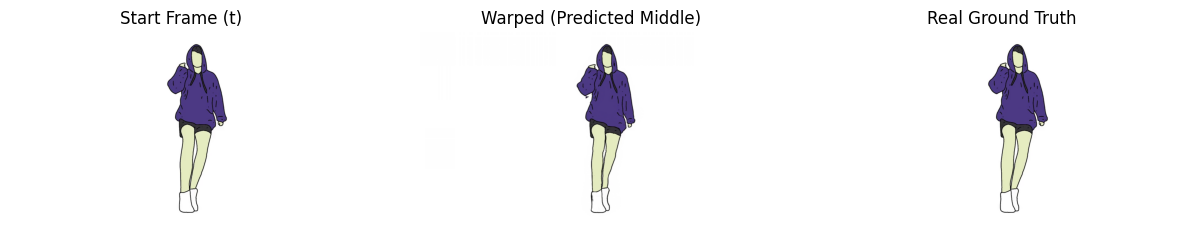

In [4]:
# --- ROBUST VISUALIZATION (CORRECTED) ---
import matplotlib.pyplot as plt
import torch
import os
import cv2
import numpy as np

print("Visualizing a sample...")

# 1. SAFETY CHECK: Ensure we actually have flow files to process
# 'flow_files' is the list we created in the previous cell.
if 'flow_files' not in locals() or len(flow_files) == 0:
    print("❌ Error: No flow files found. Did the processing loop run successfully?")
else:
    # 2. Pick the FIRST file from our list to use as a test case
    sample_flow_path = flow_files[0]
    
    # 3. RECONSTRUCT THE IMAGE PATH (The Critical Fix)
    # The flow file is at: dataset/flow/video1/00000_0.npy
    # The image file is at: dataset/triplets/video1/00000_0.png
    
    # Get the relative path (e.g., "video1/00000_0.npy")
    rel_path = os.path.relpath(sample_flow_path, INPUT_FLOW_DIR)
    
    # Replace the extension .npy with .png to find the matching image
    # Note: We do NOT need to add '_0' again because it is already in the filename!
    img_path = os.path.join(INPUT_IMG_DIR, rel_path.replace('.npy', '.png'))
    
    print(f"   Looking for image at: {img_path}") # Debug print to verify path

    if os.path.exists(img_path):
        # Load the Image and the Flow Data
        img_bgr = cv2.imread(img_path)
        flow_data = np.load(sample_flow_path)
        
        # 4. PREPARE TENSORS FOR WARPING
        # PyTorch needs data in (Batch, Channels, Height, Width) format
        # We also need to convert from Integer (0-255) to Float for math operations
        img_tensor = torch.from_numpy(img_bgr).permute(2, 0, 1).unsqueeze(0).float()
        flow_tensor = torch.from_numpy(flow_data).permute(2, 0, 1).unsqueeze(0).float()
        
        # 5. RUN THE WARP FUNCTION
        # We use torch.no_grad() because we are just testing, not training a neural network yet
        with torch.no_grad():
            warped_tensor = warp_frame(img_tensor, flow_tensor)
        
        # Convert the result back to a standard image format (Height, Width, Channels)
        # so matplotlib can display it
        warped_img = warped_tensor.squeeze(0).permute(1, 2, 0).numpy().astype(np.uint8)

        # 6. DISPLAY RESULTS SIDE-BY-SIDE
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        # Show Start Frame (Input)
        ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        ax[0].set_title("Start Frame (t)")
        ax[0].axis('off')

        # Show Warped Frame (Our Prediction)
        # This should look like the start frame pushed slightly towards the movement direction
        ax[1].imshow(cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB))
        ax[1].set_title("Warped (Predicted Middle)")
        ax[1].axis('off')

        # Show Real Middle Frame (Ground Truth)
        # We try to find the file ending in _1.png to compare against
        real_mid_path = img_path.replace('_0.png', '_1.png')
        
        if os.path.exists(real_mid_path):
            real_mid = cv2.imread(real_mid_path)
            ax[2].imshow(cv2.cvtColor(real_mid, cv2.COLOR_BGR2RGB))
            ax[2].set_title("Real Ground Truth")
            ax[2].axis('off')
        else:
            print(f"   (Could not find ground truth at {real_mid_path})")
            ax[2].axis('off')
        
        plt.show()
    else:
        print(f"❌ Still cannot find image at: {img_path}")
        print("   Please check your folder structure or filename logic.")

this code below is to check the whether the code was warped or not 

-If you see ghost lines: The code works, but the motion is too weak. (Proceed to Fix 1).
-If it is pure black: The code is broken. (Check variables).

if that middle frame was not warped frameA - frameB == 0 (makes the image look black)
if it is warped frame A -frameB != 0 (which makes it warped , just in our case)

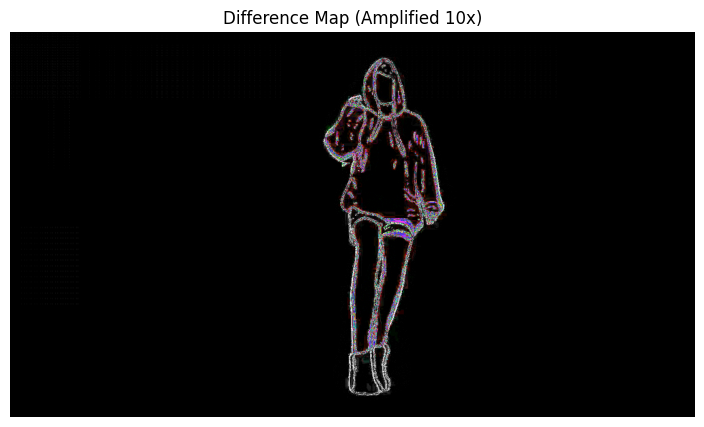

Max pixel shift intensity: 255
If Max is > 0, the image CHANGED. If Max is 0, it is an exact copy.


In [14]:
# --- DEBUGGING: THE DIFFERENCE CHECK ---
# We calculate the absolute difference between START and WARPED
# If they are identical, the result will be pure black (0).
# If they are slightly different, you will see faint gray lines.

diff = cv2.absdiff(img_bgr, warped_img)

# Amplify the difference by 10x so we can see it with human eyes
diff_amplified = diff * 10 

plt.figure(figsize=(10, 5))
plt.imshow(diff_amplified)
plt.title("Difference Map (Amplified 10x)")
plt.axis('off')
plt.show()

# Print statistics
print(f"Max pixel shift intensity: {np.max(diff)}")
print("If Max is > 0, the image CHANGED. If Max is 0, it is an exact copy.")